In [1]:
import sys
sys.path.append('../externals/DynaMix-python')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.dynamix.model.forecaster import DynaMixForecaster
from src.dynamix.utilities.plotting_eval import plot_TS_forecast, plot_3D_attractor
from src.dynamix.utilities.utilities import load_hf_model
from src.dynamix.metrics.metrics import geometrical_misalignment, temporal_misalignment, MASE

import torch

In [2]:
# load data
subj_data_path_ec = '../data/sub-19690969_ses-1_task-restEC_eeg_csv_120.016s.npy'
eeg_dict_ec = np.load(subj_data_path_ec, allow_pickle=True)
channel_labels_ec = eeg_dict_ec['labels']
sampling_freq_ec = eeg_dict_ec['Fs']
eeg_data_ec = eeg_dict_ec['data']
print("---EC---")
print("Data shape:", eeg_data_ec.shape)
print("Sampling frequency:", sampling_freq_ec)
print("Num channels:", len(channel_labels_ec))
print("Channel labels:", channel_labels_ec)

subj_data_path_eo = '../data/sub-19690969_ses-1_task-restEO_eeg_csv_119.92s.npy'
eeg_dict_eo = np.load(subj_data_path_eo, allow_pickle=True)
print(eeg_dict_eo.keys())
channel_labels_eo = eeg_dict_eo['labels']
sampling_freq_eo = eeg_dict_eo['Fs']
eeg_data_eo = eeg_dict_eo['data']
print("\n---EO---")
print("Data shape:", eeg_data_eo.shape)
print("Sampling frequency:", sampling_freq_eo)
print("Num channels:", len(channel_labels_eo))
print("Channel labels:", channel_labels_eo)

---EC---
Data shape: (1, 32, 60008)
Sampling frequency: 500
Num channels: 32
Channel labels: ['Fp1' 'Fp2' 'F7' 'F3' 'Fz' 'F4' 'F8' 'FC3' 'FCz' 'FC4' 'T7' 'C3' 'Cz'
 'C4' 'T8' 'CP3' 'CPz' 'CP4' 'P7' 'P3' 'Pz' 'P4' 'P8' 'O1' 'Oz' 'O2'
 'artifacts' 'VEOG' 'HEOG' 'Erbs' 'OrbOcc' 'Mass']
dict_keys(['artifacts', 'info', 'data', 'trl', 'artidata', 'arttrl', 'Fs', 'labels', 'neighblabels'])

---EO---
Data shape: (1, 32, 59960)
Sampling frequency: 500
Num channels: 32
Channel labels: ['Fp1' 'Fp2' 'F7' 'F3' 'Fz' 'F4' 'F8' 'FC3' 'FCz' 'FC4' 'T7' 'C3' 'Cz'
 'C4' 'T8' 'CP3' 'CPz' 'CP4' 'P7' 'P3' 'Pz' 'P4' 'P8' 'O1' 'Oz' 'O2'
 'artifacts' 'VEOG' 'HEOG' 'Erbs' 'OrbOcc' 'Mass']


In [3]:
# load the pre-trained model
model = load_hf_model("dynamix-6d-alrnn-v1.0")

# set model to evaluation mode
model.eval()

# initialize the forecaster
forecaster = DynaMixForecaster(model)

# a dict to store the activations
def getActivation(name):
    activation[name] = list()
    # the hook signature
    def hook(model, input, output):
        activation[name].append(output.detach())
    return hook

In [4]:
def get_dynamix_latent(subj_data_path):
    channel_filter = ['F7', 'P8', 'T7', 'O2']

    eeg_dict = np.load(subj_data_path, allow_pickle=True)
    channel_labels = eeg_dict['labels']
    sampling_freq = eeg_dict['Fs']

    channel_mask = np.isin(channel_labels, channel_filter)
    eeg_data = eeg_dict['data'][0, channel_mask, :]
    assert eeg_data.shape[0] == len(channel_filter)

    offset = 5000
    CL = 10000
    T = 100

    context_start = offset
    context_end = offset + CL

    # Load the time series data
    ts_data = eeg_data.T

    context_ts = ts_data[context_start:context_end,:] # context from 5000 to 15000 (10s-30s)

    # Convert to PyTorch tensor
    context_ts_tensor = torch.tensor(context_ts, dtype=torch.float32)
    
    activation = {}
    # a dict to store the activations
    def getActivation(name):
        activation[name] = list()
        # the hook signature
        def hook(model, input, output):
            activation[name].append(output.detach())
        return hook
    h = forecaster.model.gating_network.register_forward_hook(getActivation('w_exp'))

    # Make prediction
    with torch.no_grad():  # No gradient tracking needed for inference
        reconstruction_ts = forecaster.forecast(
            context=context_ts_tensor,
            horizon=T,
            preprocessing_method="pos_embedding",
            standardize=True,
            fit_nonstationary=False,
        )

    h.remove()
    w_exp = torch.stack(activation['w_exp']).numpy().squeeze()

    return w_exp

In [5]:
# try function on single subject
dynamix_ec = get_dynamix_latent(subj_data_path_ec)
dynamix_eo = get_dynamix_latent(subj_data_path_eo)
print(dynamix_ec.shape) # 100 timepoints (horizon) x 80 weights
print(dynamix_eo.shape)

KeyboardInterrupt: 

### Test out plotting functions

In [13]:
channel_filter = ['Fp1', 'Cz', 'O2']
eeg_dict_ec = np.load(subj_data_path_ec, allow_pickle=True)
channel_labels = eeg_dict_ec['labels']
sampling_freq = eeg_dict_ec['Fs']

channel_mask = np.isin(channel_labels, channel_filter)
eeg_data = eeg_dict_ec['data'][0, channel_mask, :]

In [14]:
offset = 400
T = 1000
CL = 500

context_start = offset
context_end = offset + CL

ground_truth_start = context_end
ground_truth_end = context_end + T

# Load the time series data
ts_data = eeg_data.T
print("ts_data shape:", ts_data.shape)
    
context_ts = ts_data[context_start:context_end]
ground_truth_ts = ts_data[ground_truth_start:ground_truth_end]

print(f"Time series data shape: {ts_data.shape}")
print(f"Context shape: {context_ts.shape}")
print(f"Ground truth shape: {ground_truth_ts.shape}")

ts_data shape: (60008, 3)
Time series data shape: (60008, 3)
Context shape: (500, 3)
Ground truth shape: (1000, 3)


Reconstruction shape:  (1000, 3)


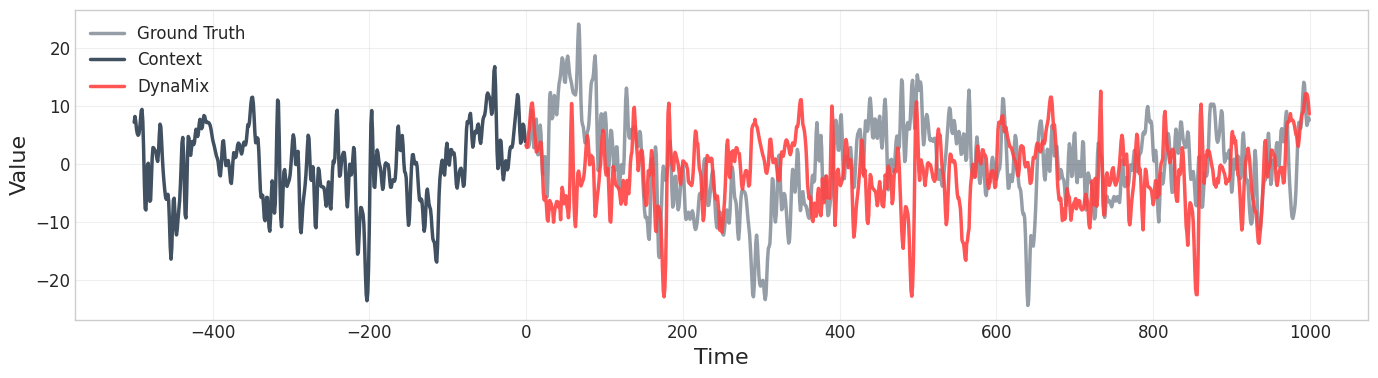

In [15]:
# Convert to PyTorch tensor
context_ts_tensor = torch.tensor(context_ts, dtype=torch.float32)

activation = {}
h = forecaster.model.gating_network.register_forward_hook(getActivation('w_exp'))

# Make prediction
with torch.no_grad():  # No gradient tracking needed for inference
    reconstruction_ts = forecaster.forecast(
        context=context_ts_tensor,
        horizon=T,
        preprocessing_method="pos_embedding",
        standardize=True,
        fit_nonstationary=False,
    )

h.remove()
    
# Convert to numpy for plotting
reconstruction_ts_np = reconstruction_ts.cpu().numpy()

print("Reconstruction shape: ", reconstruction_ts_np.shape)

# Visualize the time series forecast
fig = plot_TS_forecast(context_ts, reconstruction_ts_np, ground_truth=ground_truth_ts, lim=T) # this plots only the first channel of data
plt.show()

Geometrical Disagreement: D_stsp = 9.223345
Temporal Disagreement: D_H = 0.111996
Prediction Error: MASE = 3.555722


/oscar/home/scbao/tdbrain-model/notebooks/../externals/DynaMix-python/src/dynamix/utilities/plotting_eval.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


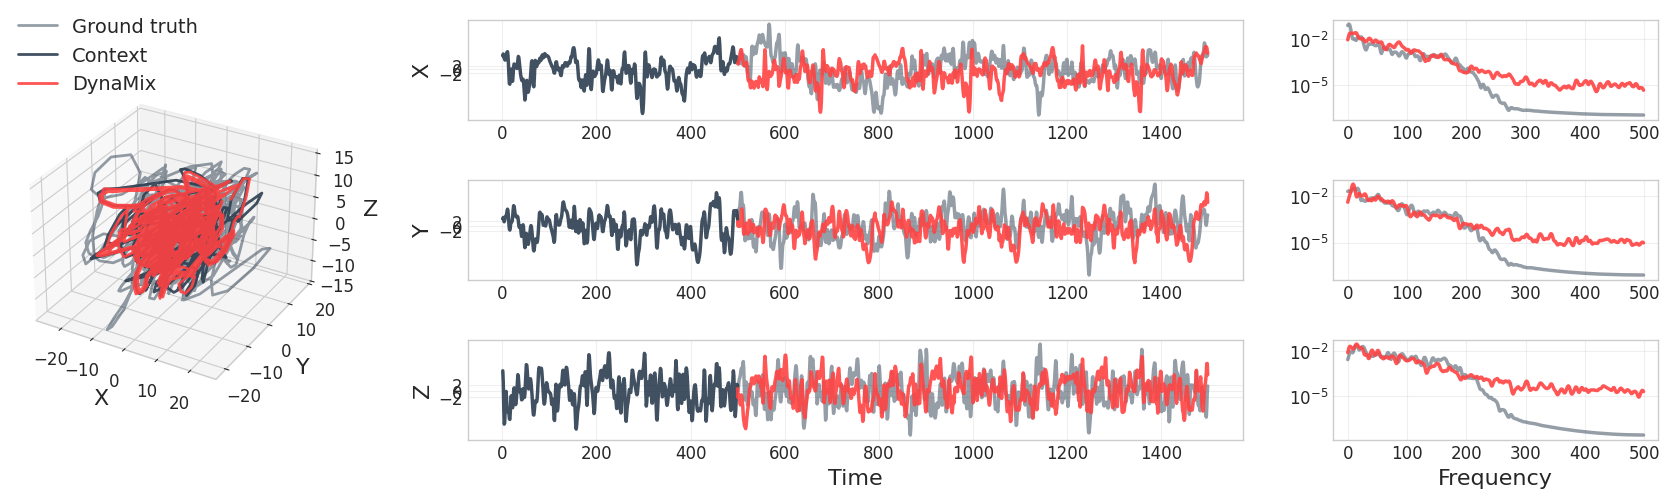

In [21]:
ground_truth_tensor = torch.tensor(ground_truth_ts[:T, :], dtype=torch.float32)
reconstruction_tensor = torch.tensor(reconstruction_ts_np[:T, :], dtype=torch.float32)

bins = 30
smoothing = 20
mase_steps = 10

dstsp = geometrical_misalignment(reconstruction_tensor, ground_truth_tensor, n_bins=bins)
dh = temporal_misalignment(reconstruction_tensor, ground_truth_tensor, smoothing=smoothing)
pe = MASE(ground_truth_tensor, reconstruction_tensor, steps=mase_steps)

print(f"Geometrical Disagreement: D_stsp = {dstsp:.6f}")
print(f"Temporal Disagreement: D_H = {dh:.6f}")
print(f"Prediction Error: MASE = {pe:.6f}")

# ----- Visualization -----
# # 3D attractor plot
# fig = plot_3D_attractor(context_ts[:CL, :], reconstruction_ts_np[:,:], ground_truth=ground_truth_ts[:T,:], lim_pse=500)
# plt.show()

# # Time series forecast plot
# fig = plot_TS_forecast(context_ts, reconstruction_ts_np, ground_truth=ground_truth_ts, lim=T)
# plt.show()

# Visualize the time series forecast
fig = plot_3D_attractor(context_ts, reconstruction_ts_np, ground_truth=ground_truth_ts, lim_gen=1000)
plt.show()